In [1]:
!pip install triton -q

In [2]:
import time
import numpy as np
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt

In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [5]:
# Create two random 1000x1000 matrices
N = 1000
A = np.random.rand(N, N).astype(np.float32)
B = np.random.rand(N, N).astype(np.float32)

# Shows the computational scale of the problem
print(f"Matrix shape: {A.shape}")
print(f"Matrix size in memory: {A.nbytes / 1024:.1f} KB each")
print(f"Total multiplications needed: {N * N * N:,}")

Matrix shape: (1000, 1000)
Matrix size in memory: 3906.2 KB each
Total multiplications needed: 1,000,000,000


In [6]:
# run 10 times and average to get a stable measurement
# a single run is noisy - the computer may have been doing
# something else in the background skewing the result
times = []
for _ in range(10):
    start = time.time()
    C = np.matmul(A, B)
    end = time.time()
    times.append(end - start)

cpu_time = sum(times) / len(times)
print(f"CPU average time: {cpu_time * 1000:.2f} ms")

CPU average time: 21.58 ms


In [7]:
# .cuda() copies data from CPU RAM into GPU VRAM
# CPU and GPU have completely separate memory
# data must be explicitly transferred before GPU can work on it
A_gpu = torch.tensor(A).cuda()
B_gpu = torch.tensor(B).cuda()

print(f"A is on: {A_gpu.device}")
print(f"B is on: {B_gpu.device}")

A is on: cuda:0
B is on: cuda:0


In [8]:
# Warmup run - GPU needs to initialize on first operation
# without this the first measurement would be artificially slow
_ = torch.matmul(A_gpu, B_gpu)
torch.cuda.synchronize()

times = []
for _ in range(10):
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    C_gpu = torch.matmul(A_gpu, B_gpu)
    end_event.record()

    # wait for GPU to actually finish before recording time
    # GPU operations are asynchronous - without this we'd measure
    # how long it took to queue the instruction, not execute it
    torch.cuda.synchronize()
    times.append(start_event.elapsed_time(end_event))

gpu_pytorch_time = sum(times) / len(times)
print(f"GPU (PyTorch) average time: {gpu_pytorch_time:.2f} ms")
print(f"Speedup over CPU: {cpu_time * 1000 / gpu_pytorch_time:.1f}x")

GPU (PyTorch) average time: 0.85 ms
Speedup over CPU: 25.4x


In [9]:
@triton.jit
def matmul_kernel(
    # Pointers to the three matrices
    A_ptr, B_ptr, C_ptr,
    # Matrix dimensions
    M, N, K,
    # Strides - how many elements to skip to move one row/column
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    # Block size - how many elements each GPU core handles
    BLOCK_SIZE: tl.constexpr,
):
    # Each GPU core figures out which block of the output
    # matrix it's responsible for using its unique ID
    pid_m = tl.program_id(axis=0)  # which row block am I?
    pid_n = tl.program_id(axis=1)  # which column block am I?

    # Calculate the starting position of my block
    row_start = pid_m * BLOCK_SIZE
    col_start = pid_n * BLOCK_SIZE

    # Create ranges for the elements I'll work on
    rows = row_start + tl.arange(0, BLOCK_SIZE)
    cols = col_start + tl.arange(0, BLOCK_SIZE)

    # Initialize accumulator - this will hold my output values
    accumulator = tl.zeros((BLOCK_SIZE, BLOCK_SIZE), dtype=tl.float32)

    # Loop through the shared dimension (K)
    # This is the actual dot product computation
    for k in range(0, K, BLOCK_SIZE):
        k_range = k + tl.arange(0, BLOCK_SIZE)

        # Load my chunk of matrix A from GPU memory
        a = tl.load(A_ptr + rows[:, None] * stride_am + k_range[None, :] * stride_ak,
                   mask=(rows[:, None] < M) & (k_range[None, :] < K), other=0.0)

        # Load my chunk of matrix B from GPU memory
        b = tl.load(B_ptr + k_range[:, None] * stride_bk + cols[None, :] * stride_bn,
                   mask=(k_range[:, None] < K) & (cols[None, :] < N), other=0.0)

        # Do the actual multiplication and accumulate
        accumulator += tl.dot(a, b)

    # Write my results back to GPU memory
    c_ptrs = C_ptr + rows[:, None] * stride_cm + cols[None, :] * stride_cn
    tl.store(c_ptrs, accumulator,
             mask=(rows[:, None] < M) & (cols[None, :] < N))

In [10]:
def matmul_triton(A, B):
    M, K = A.shape
    K, N = B.shape
    C = torch.empty((M, N), device='cuda', dtype=torch.float32)

    BLOCK_SIZE = 32

    # This defines how many GPU cores to launch
    # we need enough blocks to cover the entire output matrix
    grid = (triton.cdiv(M, BLOCK_SIZE), triton.cdiv(N, BLOCK_SIZE))

    matmul_kernel[grid](
        A, B, C,
        M, N, K,
        A.stride(0), A.stride(1),
        B.stride(0), B.stride(1),
        C.stride(0), C.stride(1),
        BLOCK_SIZE=BLOCK_SIZE,
    )
    return C

In [11]:
# Warmup
_ = matmul_triton(A_gpu, B_gpu)
torch.cuda.synchronize()

times = []
for _ in range(10):
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)

    start_event.record()
    C_triton = matmul_triton(A_gpu, B_gpu)
    end_event.record()

    torch.cuda.synchronize()
    times.append(start_event.elapsed_time(end_event))

gpu_triton_time = sum(times) / len(times)
print(f"GPU (custom kernel) average time: {gpu_triton_time:.2f} ms")
print(f"Speedup over CPU: {cpu_time * 1000 / gpu_triton_time:.1f}x")

GPU (custom kernel) average time: 1.98 ms
Speedup over CPU: 10.9x


In [12]:
# Our kernel should produce the same result as PyTorch
# correctness verification is as important as performance measurement
C_pytorch = torch.matmul(A_gpu, B_gpu)
max_diff = torch.max(torch.abs(C_triton - C_pytorch)).item()
print(f"Max difference from PyTorch result: {max_diff:.6f}")
print(f"Results match: {max_diff < 1e-3}")

Max difference from PyTorch result: 0.000534
Results match: True


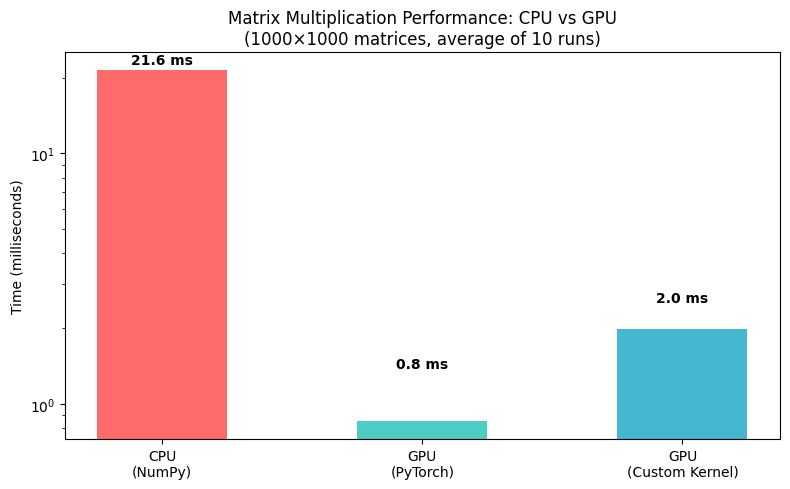


Summary:
CPU:            21.6 ms
GPU (PyTorch):  0.8 ms  (25x faster than CPU)
GPU (Kernel):   2.0 ms  (11x faster than CPU)


In [13]:
versions = ['CPU\n(NumPy)', 'GPU\n(PyTorch)', 'GPU\n(Custom Kernel)']
times_ms = [cpu_time * 1000, gpu_pytorch_time, gpu_triton_time]
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(versions, times_ms, color=colors, width=0.5)

# Add the actual time values on top of each bar
for bar, t in zip(bars, times_ms):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{t:.1f} ms', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Time (milliseconds)')
ax.set_title('Matrix Multiplication Performance: CPU vs GPU\n(1000×1000 matrices, average of 10 runs)')
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary:")
print(f"CPU:            {cpu_time*1000:.1f} ms")
print(f"GPU (PyTorch):  {gpu_pytorch_time:.1f} ms  ({cpu_time*1000/gpu_pytorch_time:.0f}x faster than CPU)")
print(f"GPU (Kernel):   {gpu_triton_time:.1f} ms  ({cpu_time*1000/gpu_triton_time:.0f}x faster than CPU)")